<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/group_r(dt).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset Preview:
   covid_concern  covid_knowledge  behavioral_antiviral_meds  \
0       1.498120        -0.480873                  -0.237211   
1       0.390024        -0.480873                  -0.237211   
2      -1.826169         1.145981                  -0.237211   
3       0.390024         1.145981                  -0.237211   
4      -0.718072        -0.480873                  -0.237211   

   behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
0              0.604394             -0.280819               0.438429   
1              0.604394             -0.280819               0.438429   
2             -1.662560             -0.280819              -2.285143   
3              0.604394             -0.280819               0.438429   
4              0.604394             -0.280819              -2.285143   

   behavioral_large_gatherings  behavioral_outside_home  \
0                     -0.74467                 1.428554   
1                     -0.74467                -

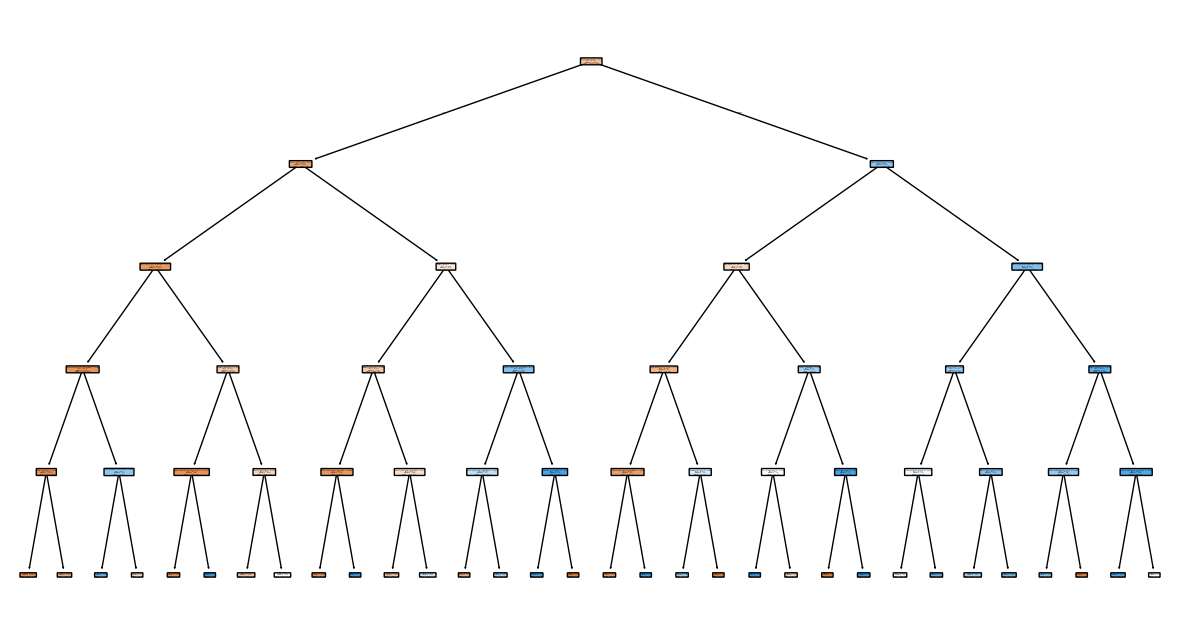

In [15]:
# Decision tree
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Dataset
df = pd.read_csv('/content/drive/MyDrive/super_dataset_C_train.csv')

# Display
print("Dataset Preview:")
print(df.head())

# Display column names
print("\nColumns:")
print(df.columns)

# Set target column
target_column = 'covid_vaccine' # Changed 'target_column' to 'covid_vaccine'

# Features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Decision Tree
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize Tree
plt.figure(figsize=(15, 8))
plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True
)
plt.show()

## Hyperparameter Tuning with GridSearchCV

To further improve the model's performance and prevent overfitting, we can perform hyperparameter tuning. GridSearchCV works on multiple combinations of parameter values, cross-validating each combination to determine which gives the best performance. We will tune parameters like max_depth, min_samples_split, min_samples_leaf, and criterion.

In [16]:
from sklearn.model_selection import GridSearchCV

#  parameter grid to search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#  GridSearchCV with class_weight='balanced'
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to training data
grid_search.fit(X_train, y_train)

# best parameters and best score
print("\nBest parameters found:", grid_search.best_params_)
print("Best cross-validation f1_weighted score:", grid_search.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best parameters found: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best cross-validation f1_weighted score: 0.7611238292463137


## Evaluate the Tuned Model

Use the best estimator found by GridSearchCV to make predictions on the test set and evaluate its performance.


Accuracy of Tuned Model: 0.7457983193277311

Classification Report of Tuned Model:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       653
           1       0.57      0.74      0.65       299

    accuracy                           0.75       952
   macro avg       0.72      0.74      0.72       952
weighted avg       0.77      0.75      0.75       952



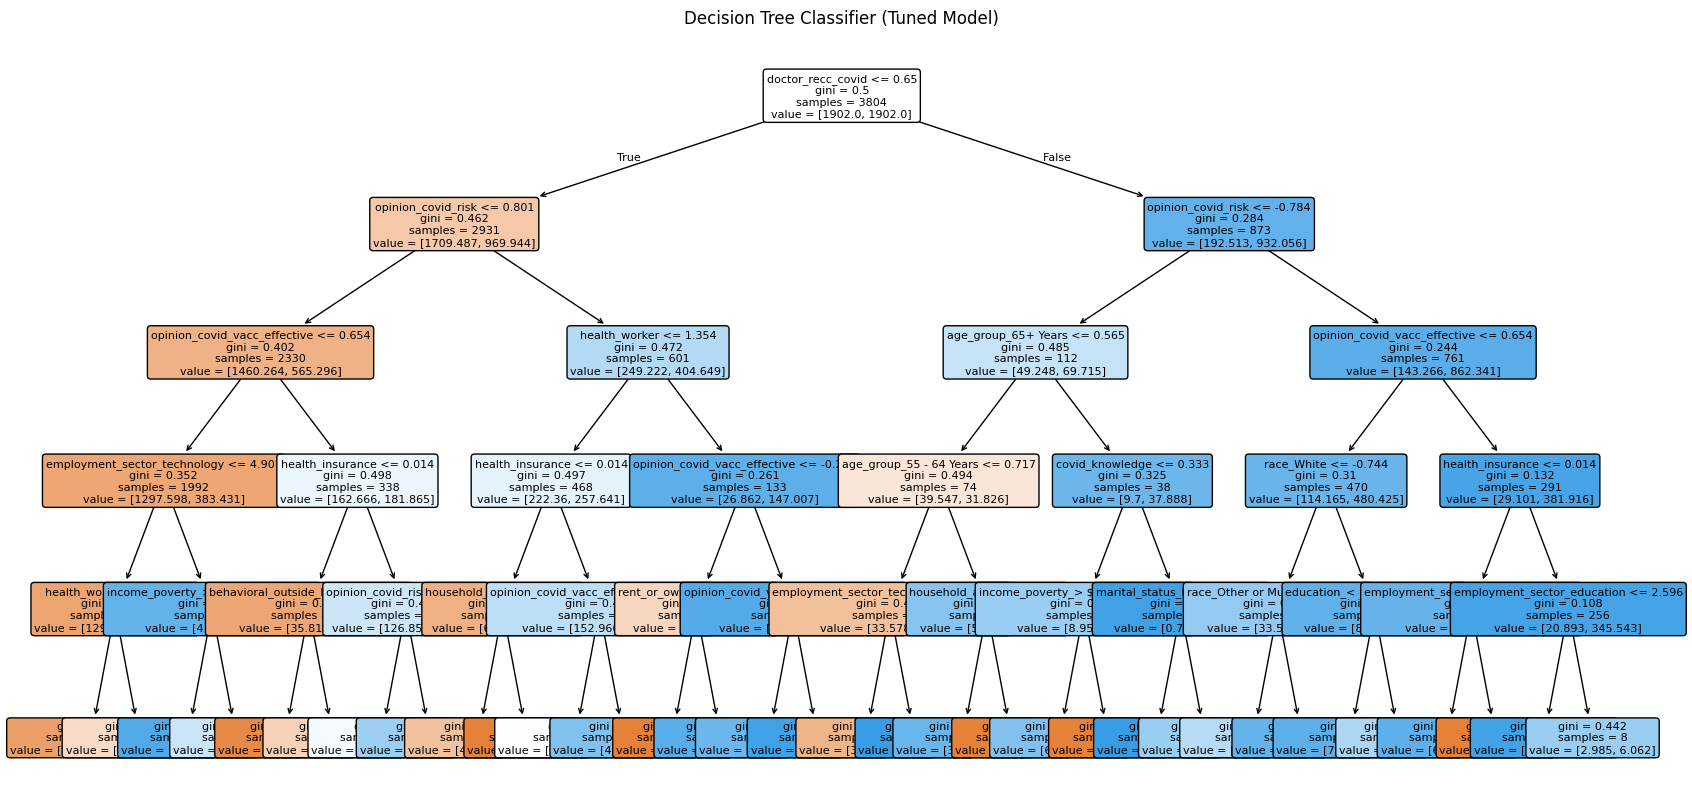

In [17]:
#  best model from the grid search
best_model = grid_search.best_estimator_

# predictions with best model
y_pred_tuned = best_model.predict(X_test)

# Evaluate the tuned model
print("\nAccuracy of Tuned Model:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report of Tuned Model:")
print(classification_report(y_test, y_pred_tuned))

# Visualize the Best model
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Classifier (Tuned Model)")
plt.show()

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# parameter distributions to sample from
param_distributions = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

# RandomizedSearchCV with class_weight='balanced'
random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit RandomizedSearchCV to  training data
print("\nFitting RandomizedSearchCV...")
random_search.fit(X_train, y_train)

# best parameters and best score
print("\nBest parameters found by RandomizedSearchCV:", random_search.best_params_)
print("Best cross-validation f1_weighted score by RandomizedSearchCV:", random_search.best_score_)


Fitting RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found by RandomizedSearchCV: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 13}
Best cross-validation f1_weighted score by RandomizedSearchCV: 0.7651560585962405


## Evaluate the Tuned Model from RandomizedSearchCV

Evaluate the performance of the best model found by RandomizedSearchCV on the test set.


Accuracy of RandomizedSearchCV Tuned Model: 0.7457983193277311

Classification Report of RandomizedSearchCV Tuned Model:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       653
           1       0.57      0.74      0.65       299

    accuracy                           0.75       952
   macro avg       0.72      0.74      0.72       952
weighted avg       0.77      0.75      0.75       952



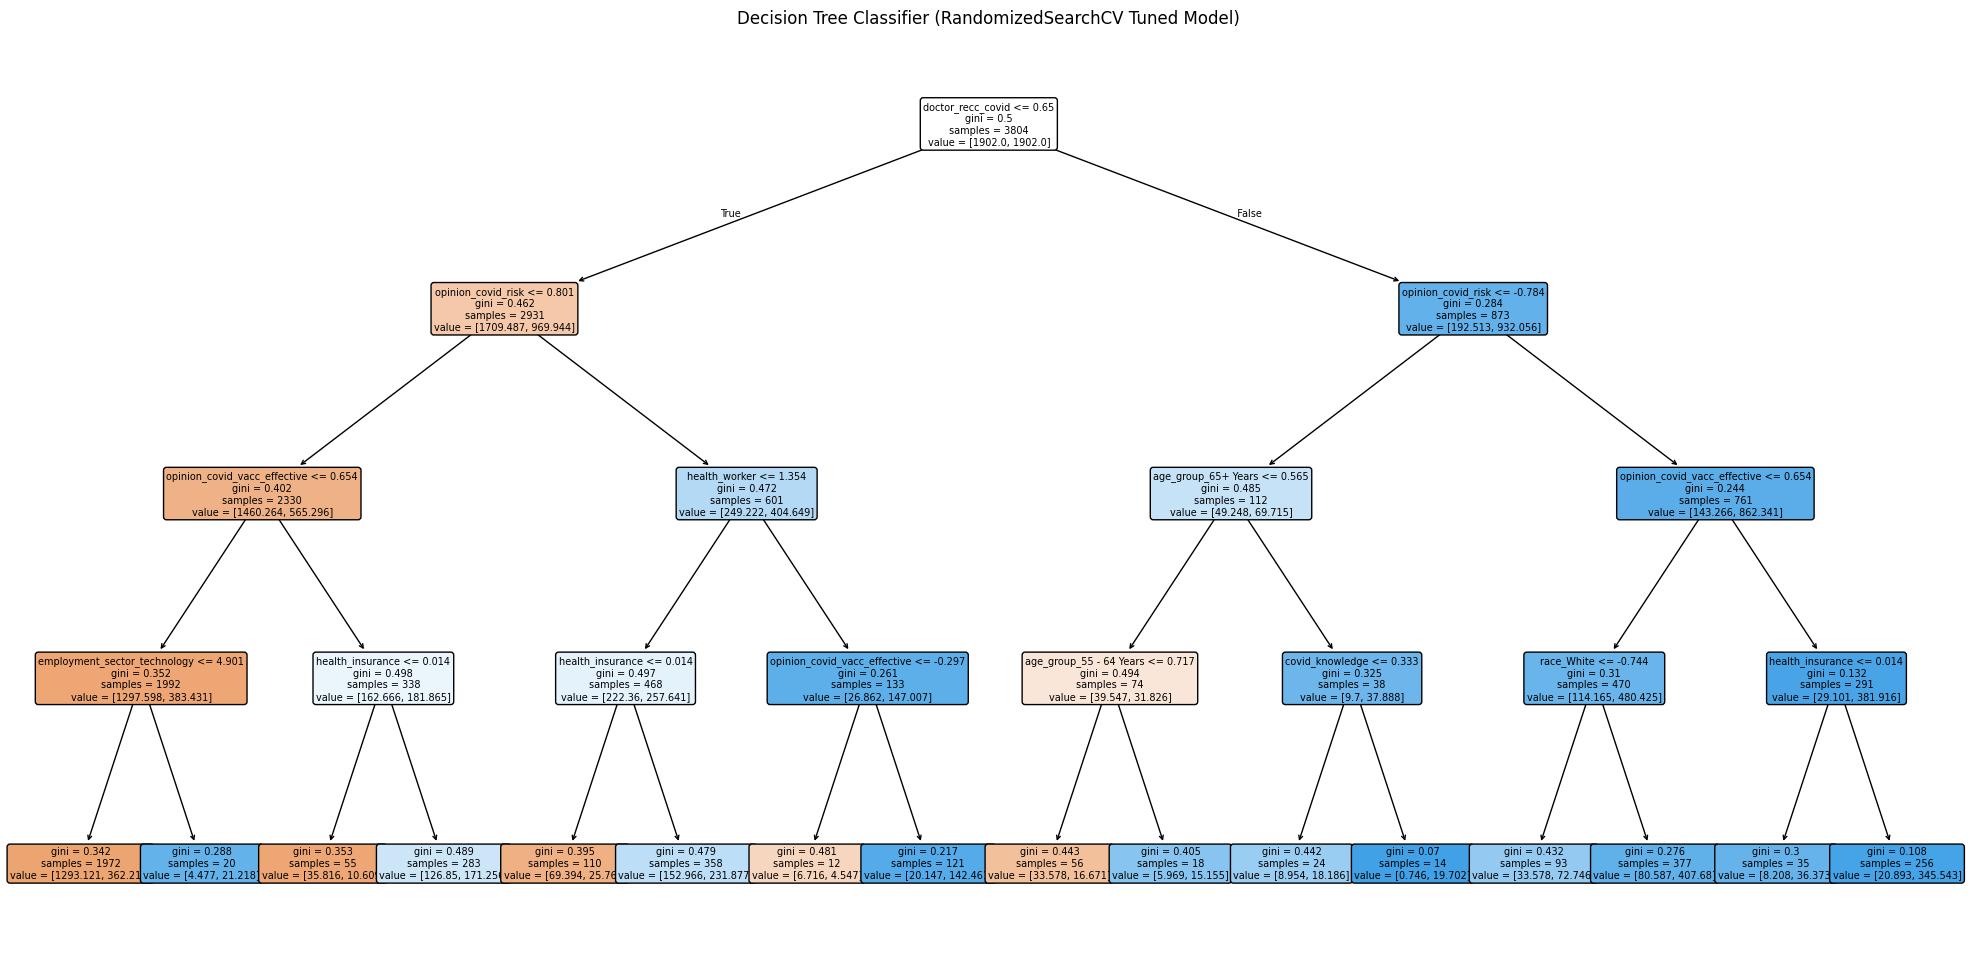

In [19]:
# best model from the randomized search
best_random_model = random_search.best_estimator_

# predictions with the best model
y_pred_random_tuned = best_random_model.predict(X_test)

# Evaluate tuned model
print("\nAccuracy of RandomizedSearchCV Tuned Model:", accuracy_score(y_test, y_pred_random_tuned))
print("\nClassification Report of RandomizedSearchCV Tuned Model:")
print(classification_report(y_test, y_pred_random_tuned))

# Visualize
plt.figure(figsize=(25, 12))
plot_tree(
    best_random_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Decision Tree Classifier (RandomizedSearchCV Tuned Model)")
plt.show()

# Applying the Tuned Model to a New Test Dataset

Load the new test dataset, apply the same preprocessing steps as the training data to ensure consistency, and then use our best_random_model to generate predictions. Finally, we'll save these predictions.

In [22]:
import pandas as pd

# Define the path to new data set
new_test_data_path = '/content/drive/MyDrive/super_dataset_C_test.csv'

# Load new test dataset
df_new_test = pd.read_csv(new_test_data_path)

# Display the head of  new test dataset
print("\nNew Test Dataset Preview:")
display(df_new_test.head())

# Assuming no explicit ID column
# test_ids = df_new_test['id_column_name']

# Applying  same categorical variable conversion  on  training data
X_new_test = pd.get_dummies(df_new_test, drop_first=True)
X_new_test = X_new_test.reindex(columns=X.columns, fill_value=0)

print("\nShape of preprocessed new test data:", X_new_test.shape)
print("\nColumns of preprocessed new test data (should match training features):\n", X_new_test.columns.tolist())



New Test Dataset Preview:


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_sector_media,employment_sector_mining,employment_sector_real_estate,employment_sector_retail,employment_sector_science,employment_sector_services,employment_sector_technology,employment_sector_transportation,employment_sector_utilities,employment_sector_wholesale
0,4757,-0.755939,-0.450851,-0.236088,0.610064,-0.296333,0.441554,-0.759835,-0.723522,-1.494767,...,-0.054376,-0.127529,-0.138198,-0.090996,-0.26699,-0.092165,-0.09332,-0.094461,-0.173643,-0.211316
1,4758,-1.850770,-2.052025,-0.236088,-1.651602,-0.296333,0.441554,-0.759835,-0.723522,-1.494767,...,-0.054376,-0.127529,-0.138198,-0.090996,-0.26699,-0.092165,-0.09332,-0.094461,-0.173643,-0.211316
2,4759,-0.755939,-0.450851,-0.236088,0.610064,-0.296333,0.441554,-0.759835,-0.723522,-1.494767,...,-0.054376,-0.127529,-0.138198,-0.090996,-0.26699,-0.092165,-0.09332,-0.094461,-0.173643,-0.211316
3,4760,1.433724,-0.450851,-0.236088,0.610064,-0.296333,0.441554,1.321646,-0.723522,-1.494767,...,-0.054376,-0.127529,-0.138198,-0.090996,-0.26699,-0.092165,-0.09332,-0.094461,-0.173643,-0.211316
4,4761,-0.755939,-0.450851,-0.236088,-1.651602,-0.296333,-2.266969,-0.759835,-0.723522,-1.494767,...,-0.054376,-0.127529,-0.138198,-0.090996,-0.26699,-0.092165,-0.09332,-0.094461,-0.173643,4.732239



Shape of preprocessed new test data: (4749, 64)

Columns of preprocessed new test data (should match training features):
 ['covid_concern', 'covid_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'household_adults', 'household_children', 'doctor_recc_covid', 'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc', 'age_group_35 - 44 Years', 'age_group_45 - 54 Years', 'age_group_55 - 64 Years', 'age_group_65+ Years', 'education_< 12 Years', 'education_College Graduate', 'education_Missing', 'education_Some College', 'race_Hispanic', 'race_Other or Multiple', 'race_White', 'sex_Male', 'income_poverty_> $75,000', 'income_poverty_Below Poverty', 'income_poverty_Missing', 'marital_status_Missing', 'marital_status_Not Married', 'ren

In [23]:
# Make predictions on the preprocessed new test data using  best_random_model
final_predictions = best_random_model.predict(X_new_test)

# Create a DataFrame for predictions

predictions_df = pd.DataFrame({'predicted_covid_vaccine': final_predictions})

print("\nPredictions generated:")
display(predictions_df.head())

# Define output path for saving predictions
output_predictions_path = '/content/drive/MyDrive/new_test_predictions.csv'

# Save predictions to a CSV file
predictions_df.to_csv(output_predictions_path, index=False)

print(f"\nPredictions saved to: {output_predictions_path}")


Predictions generated:


,predicted_covid_vaccine
0,0
1,0
2,0
3,1
4,0



Predictions saved to: /content/drive/MyDrive/new_test_predictions.csv
